# 1: Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spotify = pd.read_csv('/home/owitt/eds217/SpotifyFeatures.csv')

# 2: Explore

In [2]:
print(spotify.shape)
print(spotify.dtypes)

(232725, 18)
genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object


In [3]:
spotify.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [ ]:
spotify.isnull().sum()

In [ ]:
spotify.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [ ]:
# out of curiosity, what is the most popular song?
spotify_by_popularity = spotify.sort_values('popularity', ascending=False)
spotify_by_popularity.head(5)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
86951,Rap,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335


it looks like there are some duplicates...

# 3/4: Clean and Filter

In [ ]:
spotify = spotify.drop_duplicates(subset=['artist_name', 'track_name'])
spotify.describe()
# dropped songs that appear multiple times 
# (i.e. songs that are listed in multiple genres)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,176514.000000,176514.000000,176514.000000,1.765140e+05,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000
mean,36.257634,0.403876,0.541111,2.361540e+05,0.557203,0.172211,0.224628,-10.137290,0.127471,117.214397,0.451642
std,17.392089,0.366286,0.190441,1.305749e+05,0.275855,0.323038,0.211150,6.398382,0.204460,31.323689,0.267853
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,25.000000,0.045500,0.415000,1.782800e+05,0.344000,0.000000,0.097500,-12.850000,0.036800,92.007000,0.222000
50%,37.000000,0.288000,0.558000,2.194750e+05,0.592000,0.000071,0.130000,-8.189000,0.049400,115.009000,0.440000
75%,49.000000,0.791000,0.683000,2.685730e+05,0.789000,0.091400,0.277000,-5.629000,0.102000,138.825000,0.667000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [ ]:
# also, we need to combine the two different spellings 
# of "children's music" first into one genre
spotify['genre'] = spotify['genre'].str.replace('Children’s', 'Childrens')
spotify['genre'] = spotify['genre'].str.replace("Children's", 'Childrens')
 
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       'Childrens Music', 'Rap', 'Indie', 'Classical', 'Pop', 'Reggae',
       'Reggaeton', 'Jazz', 'Rock', 'Ska', 'Comedy', 'Soul', 'Soundtrack',
       'World'], dtype=object)

In [ ]:
spotify.describe()
# first cleaning steps done

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,176514.000000,176514.000000,176514.000000,1.765140e+05,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000
mean,36.257634,0.403876,0.541111,2.361540e+05,0.557203,0.172211,0.224628,-10.137290,0.127471,117.214397,0.451642
std,17.392089,0.366286,0.190441,1.305749e+05,0.275855,0.323038,0.211150,6.398382,0.204460,31.323689,0.267853
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,25.000000,0.045500,0.415000,1.782800e+05,0.344000,0.000000,0.097500,-12.850000,0.036800,92.007000,0.222000
50%,37.000000,0.288000,0.558000,2.194750e+05,0.592000,0.000071,0.130000,-8.189000,0.049400,115.009000,0.440000
75%,49.000000,0.791000,0.683000,2.685730e+05,0.789000,0.091400,0.277000,-5.629000,0.102000,138.825000,0.667000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


# 5: Sort

In [ ]:
# look at popular songs again:

spotify_by_popularity = spotify.sort_values('popularity', ascending=False)
spotify_by_popularity.head(5)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
86951,Rap,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
66643,Hip-Hop,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,98,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656
107875,Pop,Pedro Capó,Calma - Remix,5iwz1NiezX7WWjnCgY5TH4,97,0.3230,0.826,238200,0.773,0.000000,B,0.1430,-4.218,Minor,0.0524,126.899,4/4,0.761


In [ ]:
# what are the most popular genres?
genre_pop = spotify.groupby('genre')['popularity'].agg(['count', 'mean']) 
genre_pop_df = genre_pop.reset_index()
genres_by_pop = genre_pop_df.sort_values('mean', ascending=False)
genres_by_pop.head(5)

,genre,count,mean
16,Pop,2410,67.069295
18,Rap,1455,59.512027
21,Rock,2225,58.784270
11,Hip-Hop,7414,58.525762
8,Dance,7993,57.356187


In [ ]:
# least popular genres
genres_by_pop.tail(5)

,genre,count,mean
6,Comedy,9674,21.320240
4,Childrens Music,6669,13.397961
15,Opera,8280,13.335628
14,Movie,7801,12.143315
0,A Capella,119,9.302521


# Simple figure of a capella speechiness

In [ ]:
print(spotify['genre'].unique())

['Movie' 'R&B' 'A Capella' 'Alternative' 'Country' 'Dance' 'Electronic' 'Anime'
 'Folk' 'Blues' 'Opera' 'Hip-Hop' 'Childrens Music' 'Rap' 'Indie' 'Classical'
 'Pop' 'Reggae' 'Reggaeton' 'Jazz' 'Rock' 'Ska' 'Comedy' 'Soul' 'Soundtrack'
 'World']


In [ ]:
a_capella = spotify[spotify['genre'] == 'A Capella']

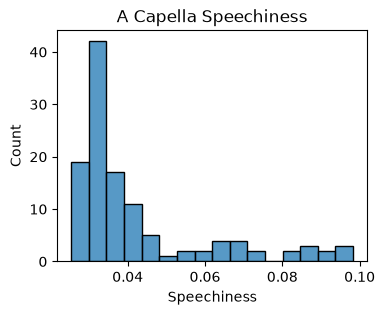

In [ ]:
plt.figure(figsize =(4,3))
sns.histplot(data=a_capella, x='speechiness')

plt.xlabel('Speechiness')
plt.title('A Capella Speechiness')
plt.show()

# Speechiness of a capella compared to other genres

In [ ]:
a_capella['speechiness'].mean()

0.0424142857142857

In [ ]:
speechiness = spotify.groupby('genre')['speechiness'].agg(['count', 'mean']) 
# a capella is a very small sample size
speechiness

,count,mean
genre,,
A Capella,119,0.042414
Alternative,9098,0.089269
Anime,8935,0.065096
Blues,8474,0.062060
Childrens Music,6669,0.108465
Classical,8703,0.051478
Comedy,9674,0.854088
Country,7382,0.048097
Dance,7993,0.085129


In [ ]:

speechy_df = speechiness.reset_index()
speechy_df
# turn back to df

,genre,count,mean
0,A Capella,119,0.042414
1,Alternative,9098,0.089269
2,Anime,8935,0.065096
3,Blues,8474,0.062060
4,Childrens Music,6669,0.108465
5,Classical,8703,0.051478
6,Comedy,9674,0.854088
7,Country,7382,0.048097
8,Dance,7993,0.085129
9,Electronic,9150,0.099696


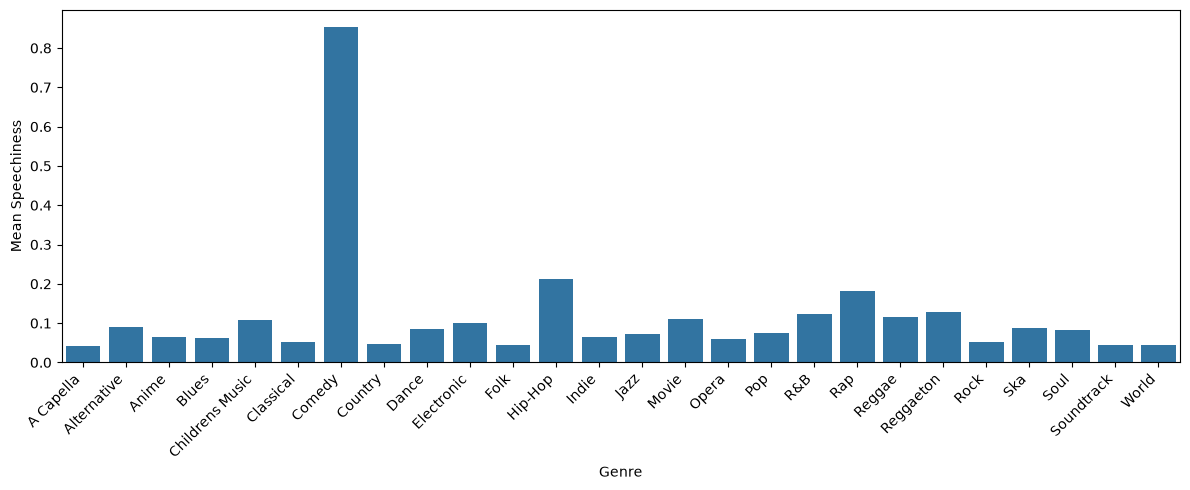

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=speechy_df, x='genre', y='mean')
plt.xlabel('Genre')
plt.ylabel('Mean Speechiness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusions: A Capella is actually less "speechy" than many other genres.  Comedy is by far the "speechiest" genre.

we might need to filter out comedy...
re-run code without comedy below:

In [ ]:
speechy_no_comedy = speechy_df[speechy_df['genre'] != "Comedy"]

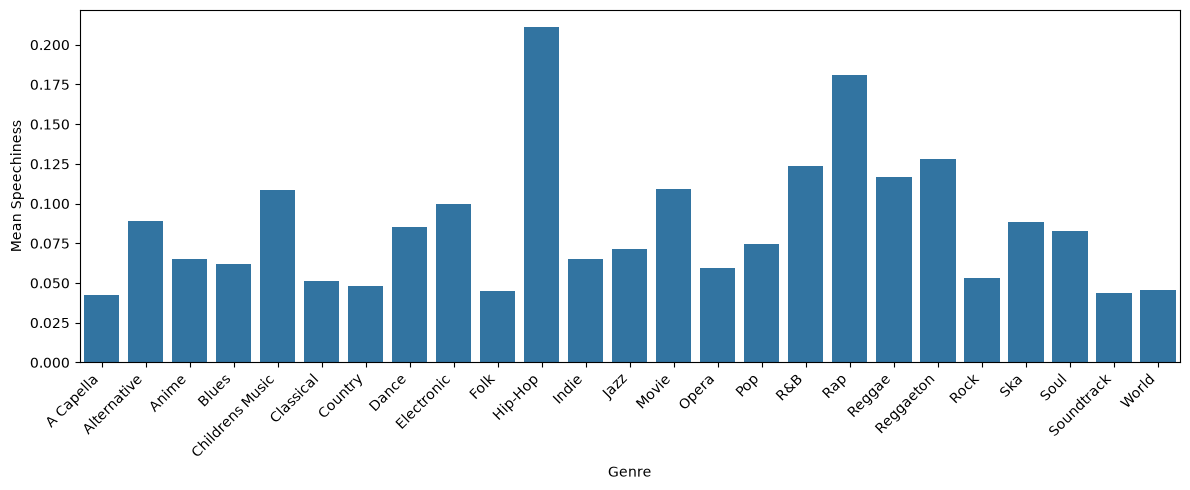

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=speechy_no_comedy, x='genre', y='mean')
plt.xlabel('Genre')
plt.ylabel('Mean Speechiness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### USE THIS FIGURE!!!


it looks like hip-hop is now the "speechiest" genre, and a capella is still on the lower end.

# Exploring Popularity vs Other Variables


For simplicity, choose three popular genres: pop, country, rock

In [ ]:
dance_genres = spotify[spotify['genre'].isin(['Pop', 'Country', 'Rock'])]

In [ ]:
danceability = dance_genres.groupby('genre')['danceability'].mean()
danceability
# seems like pop is more "danceable"

genre
Country    0.575819
Pop        0.604849
Rock       0.520322
Name: danceability, dtype: float64

In [ ]:
popularity = dance_genres.groupby('genre')['popularity'].mean()
popularity
# seems like pop is also the most popular on average

genre
Country    44.265240
Pop        67.069295
Rock       58.784270
Name: popularity, dtype: float64

In [ ]:
# turn back into dataframes and merge into one
pop_df = popularity.reset_index()
dancy_df = danceability.reset_index()

dancy_and_popy = pd.merge(dancy_df, pop_df, 
                  left_on='genre', right_on='genre')

dancy_and_popy
# don't really need this tbh

,genre,danceability,popularity
0,Country,0.575819,44.265240
1,Pop,0.604849,67.069295
2,Rock,0.520322,58.784270


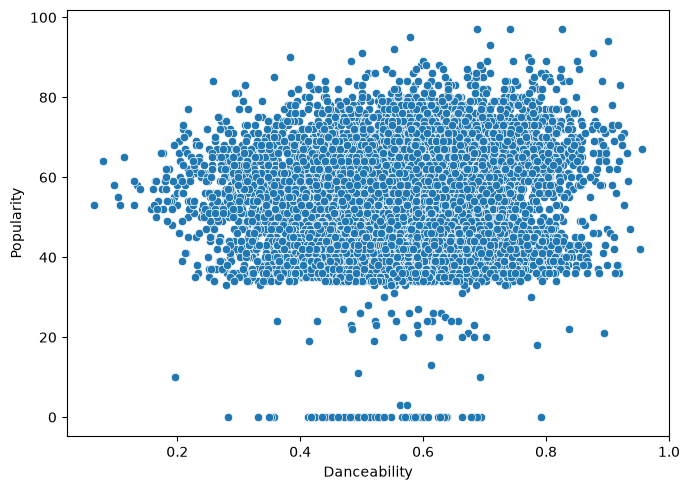

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='danceability', y='popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

There doesn't seem to be any correlation between danceability and popularity in country, rock, and pop music.

Do any variables correlate with popularity?

(still looking at country, rock, and pop)

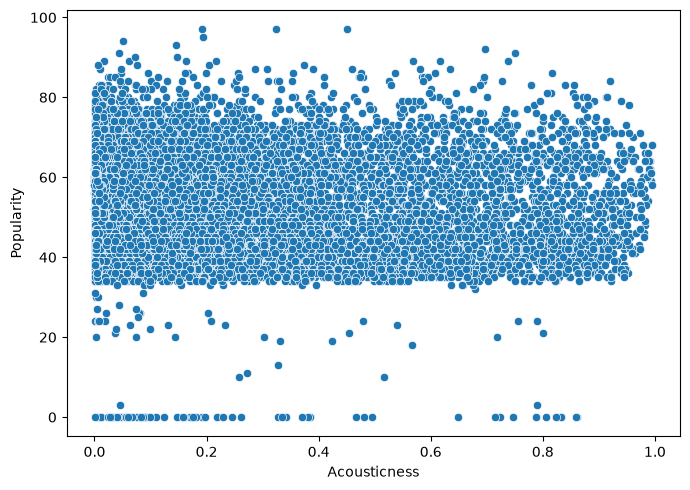

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='acousticness', y='popularity')
plt.xlabel('Acousticness')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

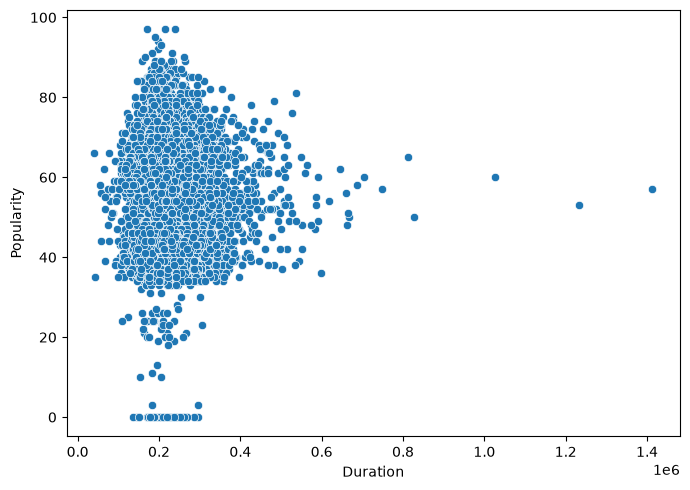

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='duration_ms', y='popularity')
plt.xlabel('Duration')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

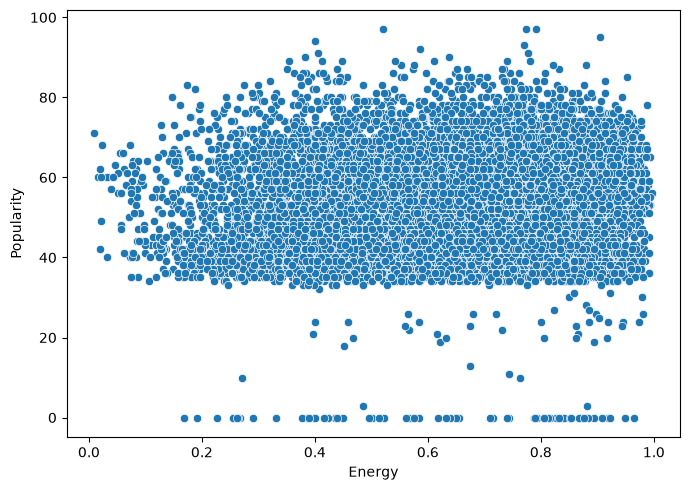

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='energy', y='popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

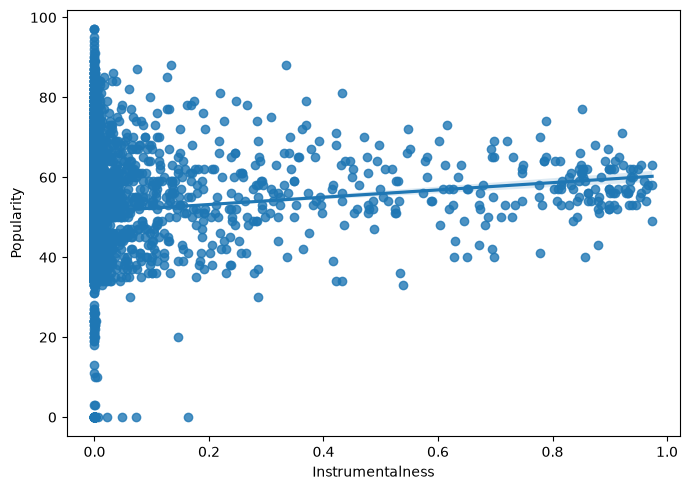

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=dance_genres, x='instrumentalness', y='popularity')
plt.xlabel('Instrumentalness')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

This is the only graph that actually seems to have a correlation.  Songs with more "instrumentalness" seem to be marginally more popular

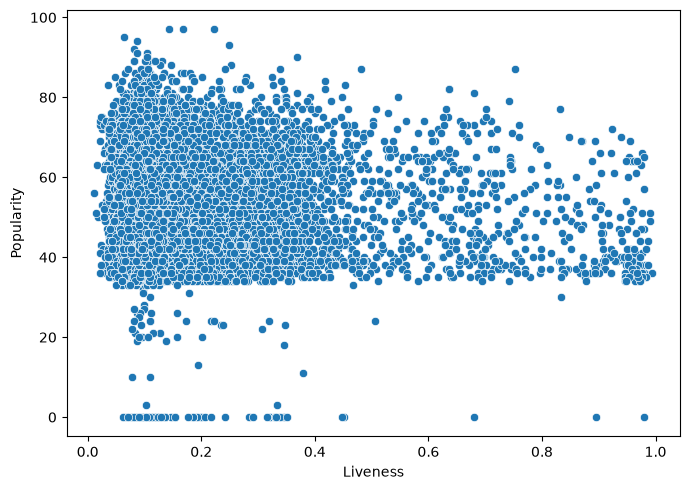

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='liveness', y='popularity')
plt.xlabel('Liveness')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

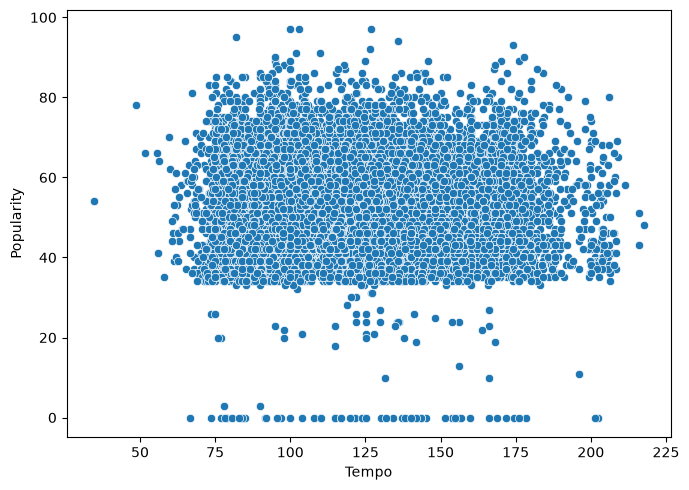

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dance_genres, x='tempo', y='popularity')
plt.xlabel('Tempo')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

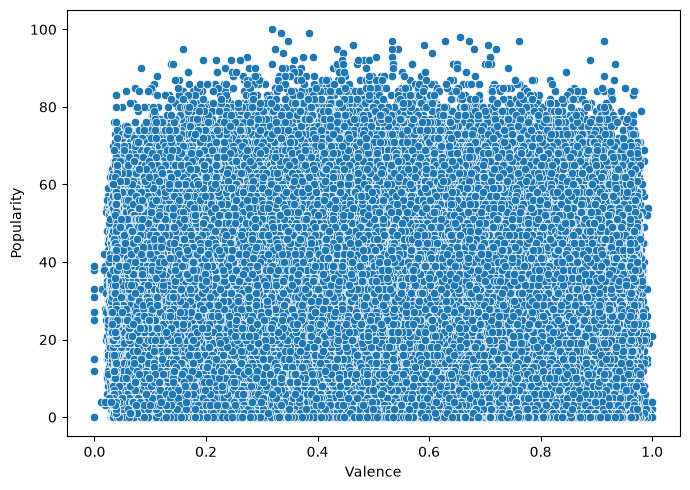

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=spotify, x='valence', y='popularity')
plt.xlabel('Valence')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

^ this is incredibly useless

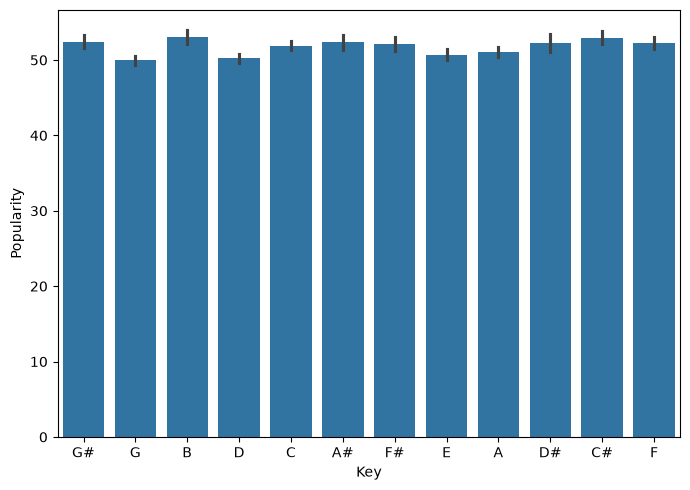

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(data=dance_genres, x='key', y='popularity')
plt.xlabel('Key')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

No variables seem to correlate strongly with popularity.  Seems like popularity isn't a great metric here. 

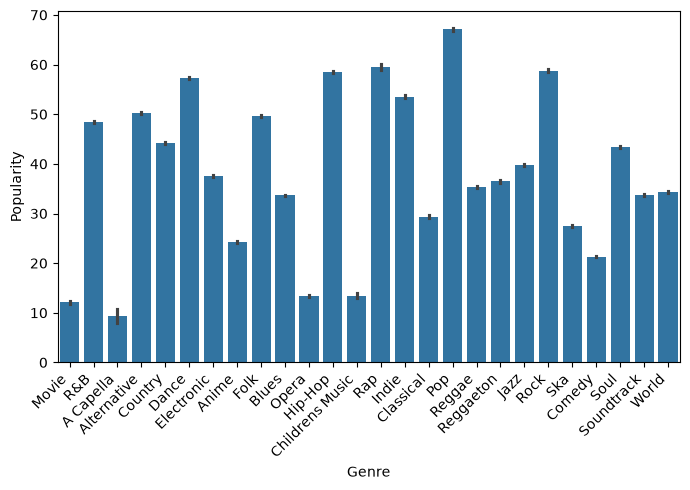

In [ ]:
# before we stop looking at popularity, lets see what the most popular genres are

plt.figure(figsize=(7, 5))
sns.barplot(data=spotify, x='genre', y='popularity')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Exploring Song Length 
Just looking at 4 genres: Pop, Rap, Classical, Opera

These are two of the most popular genres, as well as two of the least popular

In [ ]:
spotify_filtered = spotify[spotify['genre'].isin(['Pop', 'Rap', 'Classical', 'Opera'])]
spotify_filtered['genre'].unique()

array(['Opera', 'Rap', 'Classical', 'Pop'], dtype=object)

In [ ]:
spotify_filtered.head(10)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
57582,Opera,Charles Gounod,Ave Maria,2kyEgPaAW8wdpvevPnkf0Z,62,0.993,0.1320,163267,0.0195,0.888000,C,0.0569,-29.760,Major,0.0445,81.616,3/4,0.1400
57583,Opera,Richard Wagner,Tannhäuser: Overture,1U1i1HBJ5H8DY5J4fO8ySg,58,0.831,0.0843,853827,0.1820,0.926000,E,0.1970,-15.880,Major,0.0356,73.750,4/4,0.0604
57584,Opera,Giacomo Puccini,"""Nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.961,0.1710,180933,0.3080,0.005460,D,0.3190,-12.383,Major,0.0456,171.798,5/4,0.0889
57585,Opera,Gioachino Rossini,Semiramide: Overture (Live),2wG5UNal67Vkyjsdm3Ahat,2,0.896,0.2590,746600,0.1980,0.679000,A,0.6890,-19.621,Major,0.0658,158.284,4/4,0.1590
57586,Opera,Gioachino Rossini,Overture (Sinfonia),1chTrqszWQEOP4RsNuOZf7,52,0.911,0.3390,425000,0.1400,0.678000,E,0.1570,-20.598,Major,0.0470,95.975,4/4,0.2960
57587,Opera,Jules Massenet,Meditation: Méditation from Thaïs,0XfFRLi9G87t57kqZAzeef,49,0.872,0.0847,331933,0.0693,0.499000,E,0.0923,-23.230,Minor,0.0545,58.759,4/4,0.0361
57588,Opera,Giovanni Porta,"Rinaldo, HWV 7a, Act III (Ed. G. Sechi): Al mi...",2SSquujXqkSQ0yFawMWONL,5,0.977,0.4840,251989,0.1060,0.000009,G#,0.1210,-18.541,Minor,0.0472,109.541,4/4,0.4170
57589,Opera,Giuseppe Maria Orlandini,"Rinaldo, HWV 7a, Act I (Ed. G. Sechi): Un lamp...",1gB5aUIyFVxIdXx52Eh3UW,11,0.973,0.3090,203051,0.1650,0.004770,B,0.9280,-16.767,Major,0.1140,173.676,5/4,0.4440
57590,Opera,Giovanni Porta,"Rinaldo, HWV 7a, Act I (Ed. G. Sechi): Se in t...",77Z7gk2TDbSMpUbxBpKxv6,9,0.960,0.2170,521557,0.1230,0.000001,A,0.4980,-21.560,Major,0.0646,76.701,4/4,0.1370
57591,Opera,Giuseppe Maria Orlandini,"Rinaldo, HWV 7a, Act III (Ed. G. Sechi): Tanto...",4v9RUZ4zJ0hHxNvdoZg0fK,4,0.939,0.5090,209728,0.3040,0.002150,E,0.8040,-17.121,Major,0.4610,117.307,4/4,0.7390


Which genre has the longer songs? (duration_ms)

In [ ]:
spotify_filtered.groupby('genre')['duration_ms'].mean()
# classical seems to have the longer songs

genre
Classical    312981.590256
Opera        259161.092271
Pop          218439.330705
Rap          201944.816495
Name: duration_ms, dtype: float64

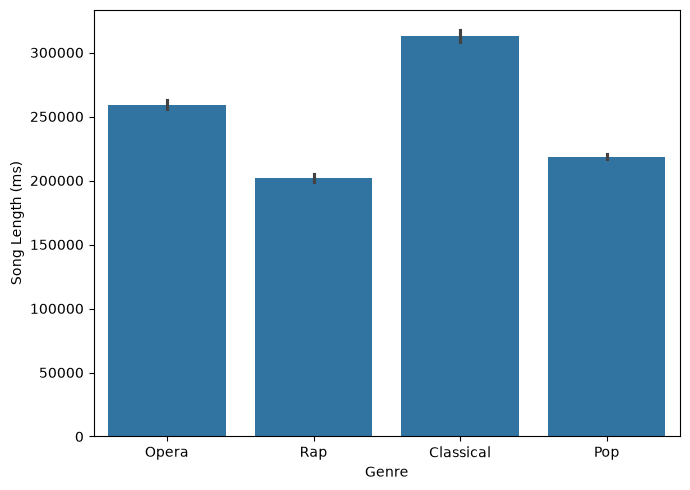

In [ ]:
# scatterplot
plt.figure(figsize=(7, 5))
sns.barplot(data=spotify_filtered, x='genre', y='duration_ms')
plt.xlabel('Genre')
plt.ylabel('Song Length (ms)')
plt.tight_layout()
plt.show()

In [ ]:
# looking at duration in more detail
grouped = spotify_filtered.groupby('genre')['duration_ms'].agg(['mean', 'max', 'min', 'count'])
filtered_df = grouped.reset_index()
filtered_df

,genre,mean,max,min,count
0,Classical,312981.590256,3391040,15509,8703
1,Opera,259161.092271,2404810,30707,8280
2,Pop,218439.330705,645876,89520,2410
3,Rap,201944.816495,760973,49242,1455


In [ ]:
classical = spotify_filtered[spotify_filtered['genre'] == "Classical"]
opera = spotify_filtered[spotify_filtered['genre'] == "Opera"]
pop = spotify_filtered[spotify_filtered['genre'] == "Pop"]
rap = spotify_filtered[spotify_filtered['genre'] == "Rap"]
# create one data frame for each genre containing only that genre

In [ ]:
# how many rows does each of these have? 
# (i.e. how many songs does each genre have?)

print(f"there are {len(classical)} classical songs")
print(f"there are {len(opera)} opera songs")
print(f"there are {len(pop)} pop songs")
print(f"there are {len(rap)} rap songs")

there are 8703 classical songs
there are 8280 opera songs
there are 2410 pop songs
there are 1455 rap songs


In [ ]:
# filter for songs above a certain threshold
# lets say a "long" song is over eight minutes
# 8 minutes is 480,000 milliseconds
8 * 60 * 1000

long_classical = classical[classical['duration_ms'] > 480000]
print(f"there are {len(long_classical)} long classical songs")
percent_classical = ((len(long_classical)) / (len(classical))) * 100
print(f"{round(percent_classical, 2)}% of classical songs are long")

print(" ")

long_opera = opera[opera['duration_ms'] > 480000]
print(f"there are {len(long_opera)} long opera songs")
percent_opera = ((len(long_opera)) / (len(opera))) * 100
print(f"{round(percent_opera, 2)}% of opera songs are long")

print(" ")

long_pop = pop[pop['duration_ms'] > 480000]
print(f"there are {len(long_pop)} long pop songs")
percent_pop = ((len(long_pop)) / (len(pop))) * 100
print(f"{round(percent_pop, 2)}% of pop songs are long")

print(" ")

long_rap = rap[rap['duration_ms'] > 480000]
print(f"there are {len(long_rap)} long rap songs")
percent_rap = ((len(long_rap)) / (len(rap))) * 100
print(f"{round(percent_rap, 2)}% of rap songs are long")

there are 1292 long classical songs
14.85% of classical songs are long
 
there are 633 long opera songs
7.64% of opera songs are long
 
there are 5 long pop songs
0.21% of pop songs are long
 
there are 6 long rap songs
0.41% of rap songs are long


In [ ]:
# set up data for graphing

def islong(d):
    if d > 480000:
        return "long"
    elif d < 180000:
        return "short"
    else:
        return "normal"

spotify_filtered['is long?'] = spotify_filtered['duration_ms'].apply(islong)

<positron-console-cell-219>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


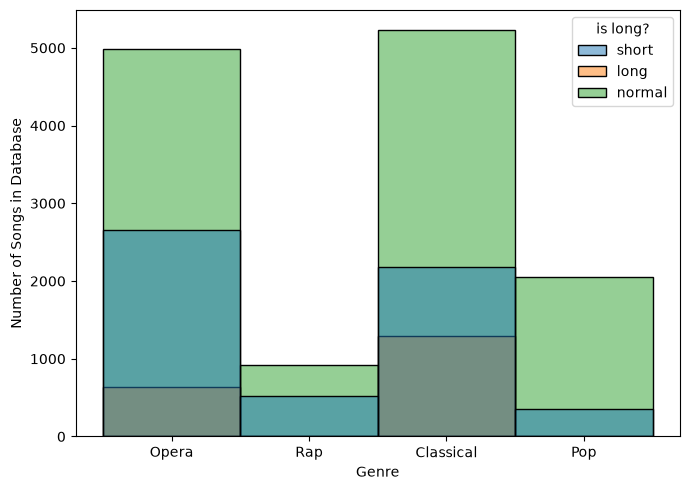

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [ ]:
# using our three selected genres
plt.figure(figsize=(7, 5))
sns.histplot(data=spotify_filtered, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")


### USE THIS FIGURE!!!

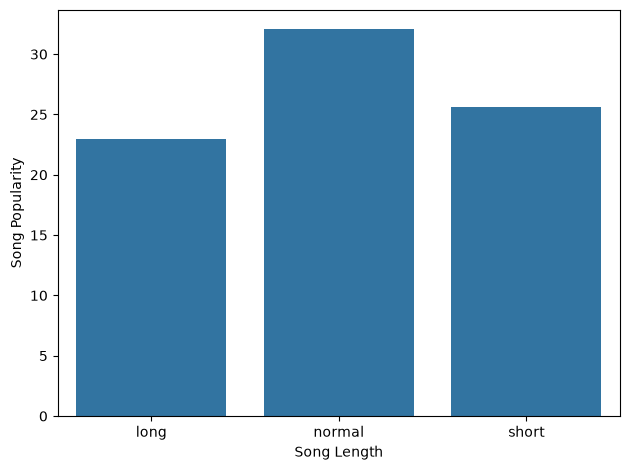

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [ ]:
# compare popularity of long vs not long songs
song_long = spotify_filtered.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

### USE THIS FIGURE!!!

## Same figures with the WHOLE database (all genres)

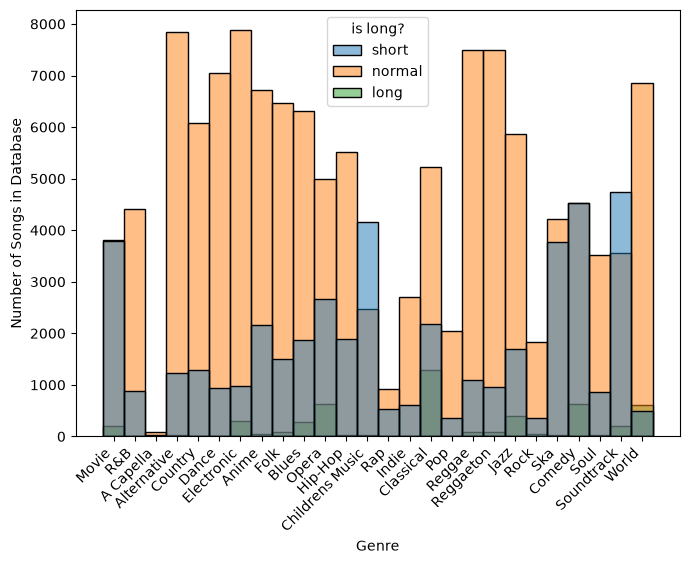

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [ ]:
# lets go back and look at the WHOLE database:
spotify['is long?'] = spotify['duration_ms'].apply(islong)


plt.figure(figsize=(7, 5))
sns.histplot(data=spotify, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

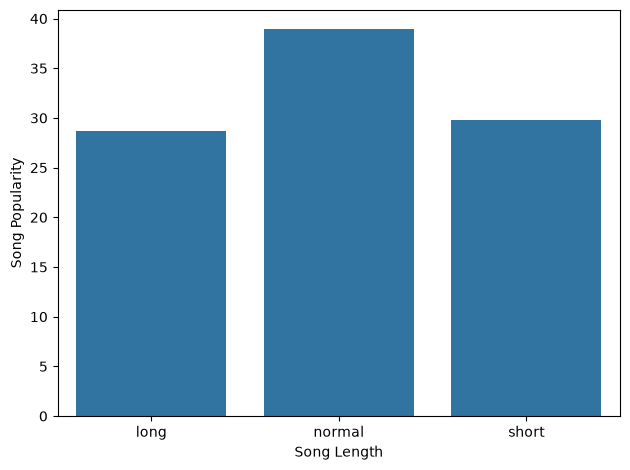

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [ ]:
all_song_long = spotify.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=all_song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")
